In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pocomc
from astropy.io import fits
from astropy.wcs import WCS, utils
import yaml
from astropy import units as u
import scipy
import multiprocess
import corner
#from photutils.profiles import RadialProfile

import initial_params
import tools
import models

def get_config_file(config_file):
    with open(config_file, 'r') as stream:
        try:
            config_data = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
    return config_data

# 1 arcsec = 8.517 kpc 
#160 arcsec = 1.325 Mpc -> non dovrebbe essere 1.36275 (8.28)
#94 arcsec = 790 kpc -> doverbbe essere 800.598. (8.40)

#D_A =  1756.7 Mpc (https://www.astro.ucla.edu/~wright/CosmoCalc.html, mettendo H0=67.66 , OmegaM = 0.3111, z=1.2, Flat -> Planck2018)

#n_e/n_p = 1.197
#N_p (main subcluster) = 8363
#N_p (west subcluster) = 1884

In [2]:
cfg = get_config_file('./config_MOO1142.yaml')
path = cfg['data']['gen_path']
fit_method = cfg['fit_method']

map_name = cfg['data']['map_file']
psf_main_name = cfg['data']['psf_main_file']
psf_sub_name = cfg['data']['psf_sub_file']
exp_main_name = cfg['data']['exp_main_file']
exp_sub_name = cfg['data']['exp_sub_file']
bkg_name = cfg['data']['bkg_file']

map_file=fits.open(path + map_name)
psf_main_file=fits.open(path + psf_main_name)
psf_sub_file=fits.open(path + psf_sub_name)
exp_main_file=fits.open(path + exp_main_name)
#wcs_north = WCS(exp_north_file[0].header)
exp_sub_file=fits.open(path + exp_sub_name)
#wcs_south = WCS(exp_south_file[0].header)
bkg_file=fits.open(path + bkg_name)

header=map_file[0].header
wcs=WCS(header)
map_data = map_file[0].data
map_data = map_data.astype(float)
psf_main_map=psf_main_file[0].data
psf_sub_map=psf_sub_file[0].data
exp_main_map_raw=exp_main_file[0].data
#Xdim_exp=map_file[0].header['NAXIS1']  
#Ydim_exp=map_file[0].header['NAXIS2']
exp_main_map_norm = exp_main_map_raw /  np.max(exp_main_map_raw)
store_exp_main_norm_factor = np.max(exp_main_map_raw)
exp_sub_map_raw=exp_sub_file[0].data
#Xdim_exp=map_file[0].header['NAXIS1']  
#Ydim_exp=map_file[0].header['NAXIS2']
exp_sub_map_norm = exp_sub_map_raw /  np.max(exp_sub_map_raw)
store_exp_sub_norm_factor = np.max(exp_sub_map_raw)
#Xdim_exp=map_file[0].header['NAXIS1']  
#Ydim_exp=map_file[0].header['NAXIS2']

#set the pixel with zero exposure to nan
e_min = cfg['min_exposure']
exp_main_map = np.where(exp_main_map_norm>e_min, exp_main_map_norm, np.nan)
exp_main_map = exp_main_map.astype(float)
exp_sub_map = np.where(exp_sub_map_norm>e_min, exp_sub_map_norm, np.nan)
exp_sub_map = exp_sub_map.astype(float)

bkg_map=bkg_file[0].data
#Xdim_bkg=map_file[0].header['NAXIS1']  
#Ydim_bkg=map_file[0].header['NAXIS2']
bkg_map = bkg_map.astype(float)

map_data=map_data[1:85,16:100]
exp_main_map=exp_main_map[1:85,16:100]
exp_sub_map=exp_sub_map[1:85,16:100]
bkg_map=bkg_map[1:85,16:100]
Xdim=np.shape(map_data)[1] 
Ydim=np.shape(map_data)[0]



the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-END to 58839.579120 from DATE-END'. [astropy.wcs.wcs]


In [ ]:
def log_likelihood (var):            
    x_main, y_main, x_sub, y_sub, rs_main, rc_sub, beta_main, beta_sub,  A_main, A_sub, a_bkg = var 
    
    mod_main = models.GNFW_model_cluster_circ(x, y, x_main, y_main, rs_main, beta_main, alpha_main, gamma_main, A_main)
    mod_sub = models.beta_model_cluster_circ(x, y, x_sub, y_sub, rc_sub, beta_sub, A_sub)
    
    map_model = models.exp(1, exp_main_map)*(tools.convolve(mod_main, psf_main_map)) +\
                models.exp(1, exp_sub_map)*(tools.convolve(mod_sub, psf_sub_map)) +\
                models.bkg(a_bkg, bkg_map)
        
    c = np.nansum(map_model - map_data*np.log(map_model)) + c0
    
    return -0.5*c

def stirling(n):
    if n == 0:
        return 1
    else:
        return n*np.log(n)-n

stirling = np.vectorize(stirling)

c0 = 2*np.nansum(stirling(map_data))

dim_pix=cfg['dim_pixel']*u.deg.to('arcmin')

# Create the map for the model
x = np.arange(0, Xdim, 1)
y = np.arange(0, Ydim, 1)
x,y = np.meshgrid(x,y)

alpha_main = 2.26
gamma_main = 0.465
x_main_in, y_main_in, x_sub_in, y_sub_in, rs_main_in, rc_sub_in, beta_main_in, beta_sub_in, \
A_main_in, A_sub_in = initial_params.init_cond_cls('gnfw_circ+beta_circ') 
a_bkg_in = initial_params.init_cond_cal()
rs_main_in = np.array(rs_main_in)/dim_pix
rc_sub_in = np.array(rc_sub_in)/dim_pix
var = [x_main_in, y_main_in, x_sub_in, y_sub_in, rs_main_in, rc_sub_in, beta_main_in,\
           beta_sub_in, A_main_in, A_sub_in, a_bkg_in] 
pdist = []
for par in var:
    loc   = par[0]
    scale = par[1]-loc
    pdist.append(scipy.stats.uniform(loc=loc,scale=scale+loc))
prior = pocomc.Prior(pdist)
nlive = 1000

resume_state_path = '/Users/eleonora/Desktop/MOO1142/fit/gnfw_circ+beta_circ_acfixed_NESTED/pmc_final.state'
sampler = pocomc.Sampler(likelihood = log_likelihood,
                         prior = prior,
                         n_effective = nlive,
                         n_active = nlive//2,
                        random_state = 0)
sampler.load_state(path=resume_state_path)

samples, weights, logl, _ = sampler.posterior()

ndim = len(var)  # number of parameters
pnum = np.copy(ndim)
results = np.empty((3,pnum))

pout = np.empty((3,pnum))
for pi in range(pout.shape[1]):
    qi = corner.quantile(samples[:,pi],[0.16,0.50,0.84],weights=weights)
    pout[:,pi] = np.array([qi[1],*np.diff(qi)])
print('68 percent CL', pout.T)

for pi in range(results.shape[1]):
    qi = corner.quantile(samples[:,pi],[0.05,0.50,0.95],weights=weights)
    results[:,pi] = np.array([qi[1],*np.diff(qi)])
results = results.T
print('90 percent CL', results)



(5116, 11)
11
68 percent CL [[3.74921190e+01 6.44741991e-02 5.30396230e-02]
 [3.98378553e+01 1.30683439e-01 1.38917004e-01]
 [5.03777150e+01 3.30536268e-01 3.29669278e-01]
 [4.27450222e+01 2.76995343e-01 2.63075143e-01]
 [1.73490306e+00 2.34714753e-01 3.80330964e-01]
 [9.55617271e+00 1.07618266e+00 8.10571480e-01]
 [4.10444589e+00 2.55747851e-01 4.48714031e-01]
 [2.56011445e+00 3.46581480e-01 6.12638278e-01]
 [9.47567899e+02 6.49618212e+01 3.52761066e+01]
 [8.28997003e+01 1.31049438e+01 2.05129544e+01]
 [9.39863072e-01 3.39892124e-02 3.27955058e-02]]
90 percent CL [[3.74921190e+01 1.21034756e-01 1.04555818e-01]
 [3.98378553e+01 2.13793363e-01 2.38141912e-01]
 [5.03777150e+01 5.68966466e-01 5.38398596e-01]
 [4.27450222e+01 4.58627430e-01 4.49370757e-01]
 [1.73490306e+00 3.41603936e-01 8.61054688e-01]
 [9.55617271e+00 1.78796432e+00 1.07745118e+00]
 [4.10444589e+00 3.64341427e-01 1.22667498e+00]
 [2.56011445e+00 4.52218190e-01 1.14252970e+00]
 [9.47567899e+02 1.23061820e+02 4.61983432e+0

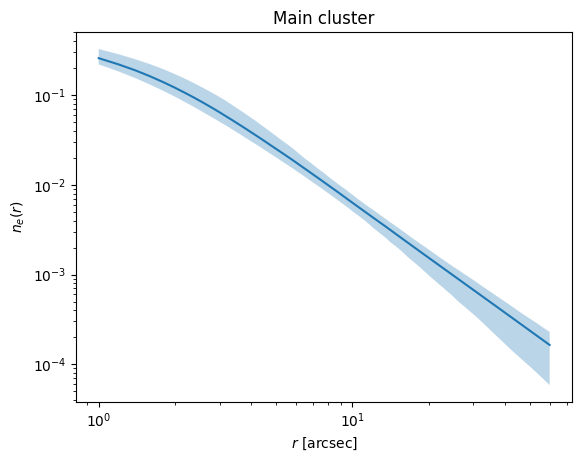

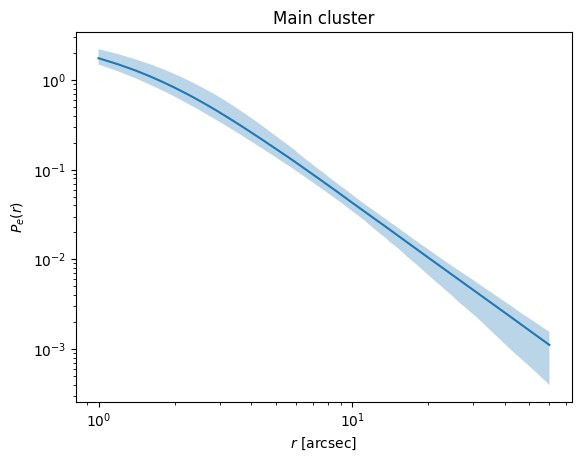

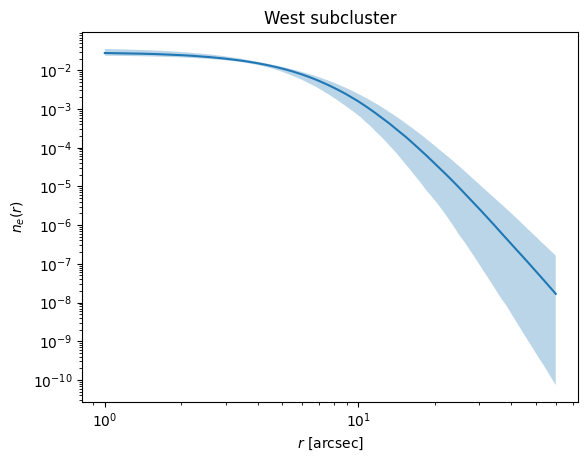

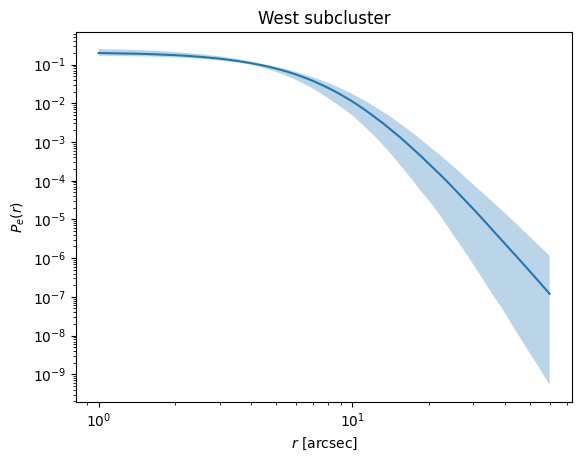

In [ ]:
def gNFW(n_s, r_kpc, r_s, alpha, beta, gamma):
    return n_s * (r_kpc/r_s)**(-gamma) * (1 + (r_kpc/r_s)**alpha)**((gamma - beta)/alpha)

def isobeta(n0, r_kpc, r_c, beta):
    return n0 * (1 + (r_kpc/r_c)**2)**(-3*beta/2)

R_vals = np.linspace(1, 60, 300) # arcsec

#main = gNFW(0.241, R_vals, 4.33, 2.26, 2.05, 0.465)
#plt.loglog(R_vals, main)
#plt.fill_between(R_vals, main_minunc, main_majunc, alpha=0.3)
F_s_main = 1.632e4 #photons*cm6/pixelˆ3
kT_main_keV = 6.76 #keV
n_profiles_main = []
P_profiles_main = []
for i in range(1000):
    #idx=np.random.randint(int(len(samples) - len(samples)/4), len(samples))
    x_main_mcmc, y_main_mcmc, x_sub_mcmc, y_sub_mcmc, rs_main_mcmc, rc_sub_mcmc, beta_main_mcmc, beta_sub_mcmc, A_main_mcmc, A_sub_mcmc, a_bkg_mcmc  = (samples[-i])

    main = lambda r : gNFW(np.sqrt(A_main_mcmc/F_s_main), r, rs_main_mcmc, alpha_main, beta_main_mcmc/2, gamma_main)
    n_profiles_main.append(main(R_vals))
    P_profiles_main.append(kT_main_keV*main(R_vals))
n_p5_main, n_p50_main, n_p95_main = np.percentile(n_profiles_main, [5, 50, 95], axis=0)
P_p5_main, P_p50_main, P_p95_main = np.percentile(P_profiles_main, [5, 50, 95], axis=0)

plt.loglog(R_vals, n_p50_main)
plt.fill_between(R_vals, n_p5_main, n_p95_main, alpha=0.3)
plt.xlabel(r'$r$ [arcsec]')
plt.ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
plt.title('Main cluster')
plt.show()

plt.loglog(R_vals, P_p50_main)
plt.fill_between(R_vals, P_p5_main, P_p95_main, alpha=0.3)
plt.xlabel(r'$r$ [arcsec]')
plt.ylabel(r'$P_e(r)$')# [cm$^{-3}$]')
plt.title('Main cluster')
plt.show()

#sub = isobeta(0.029, R_vals, 23.9, 2.56)
#plt.loglog(R_vals, sub)
#plt.fill_between(R_vals, sub_minunc, sub_majunc, alpha=0.3)
F_s_sub = 2.597e5 #photons*cm6/pixelˆ3
kT_sub_keV = 7.13 #keV
n_profiles_sub = []
P_profiles_sub = []
for i in range(1000):
    #idx=np.random.randint(int(len(samples) - len(samples)/4), len(samples))
    x_main_mcmc, y_main_mcmc, x_sub_mcmc, y_sub_mcmc, rs_main_mcmc, rc_sub_mcmc, beta_main_mcmc, beta_sub_mcmc, A_main_mcmc, A_sub_mcmc, a_bkg_mcmc  = (samples[-i])

    sub = lambda r : isobeta(np.sqrt(A_sub_mcmc * scipy.special.gamma(3*beta_sub_mcmc)/ (F_s_sub*scipy.special.gamma(3*beta_sub_mcmc - 0.5))), r, rc_sub_mcmc, beta_sub_mcmc)
    n_profiles_sub.append(sub(R_vals))
    P_profiles_sub.append(kT_sub_keV*sub(R_vals))
n_p5_sub, n_p50_sub, n_p95_sub = np.percentile(n_profiles_sub, [5, 50, 95], axis=0)
P_p5_sub, P_p50_sub, P_p95_sub = np.percentile(P_profiles_sub, [5, 50, 95], axis=0)

plt.loglog(R_vals, n_p50_sub)
plt.fill_between(R_vals, n_p5_sub, n_p95_sub, alpha=0.3)
plt.xlabel(r'$r$ [arcsec]')
plt.ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
plt.title('West subcluster')
plt.show()

plt.loglog(R_vals, P_p50_sub)
plt.fill_between(R_vals, P_p5_sub, P_p95_sub, alpha=0.3)
plt.xlabel(r'$r$ [arcsec]')
plt.ylabel(r'$P_e(r)$')# [cm$^{-3}$]')
plt.title('West subcluster')
plt.show()


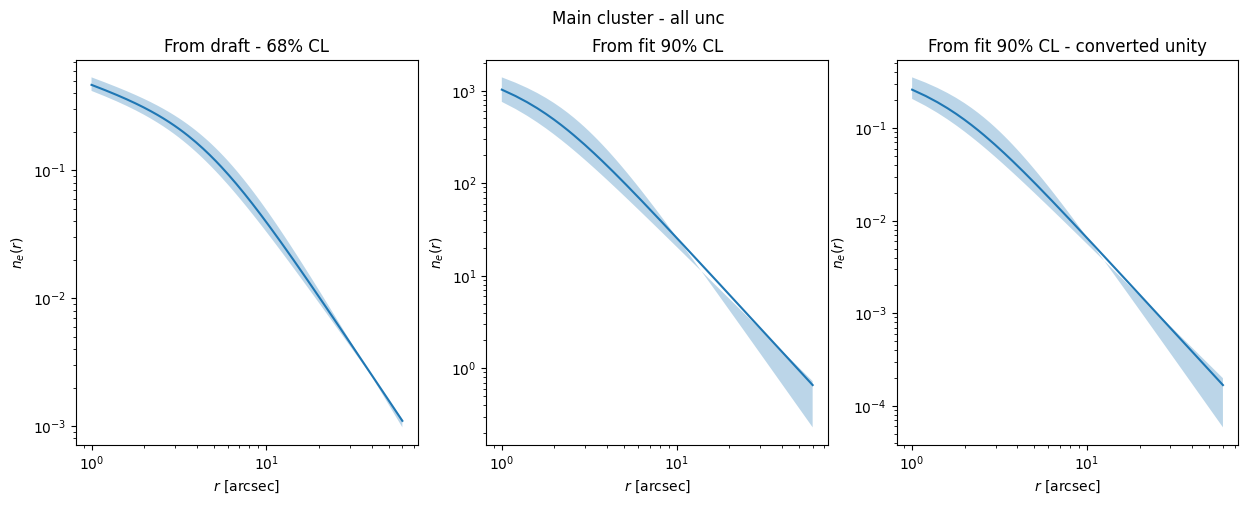

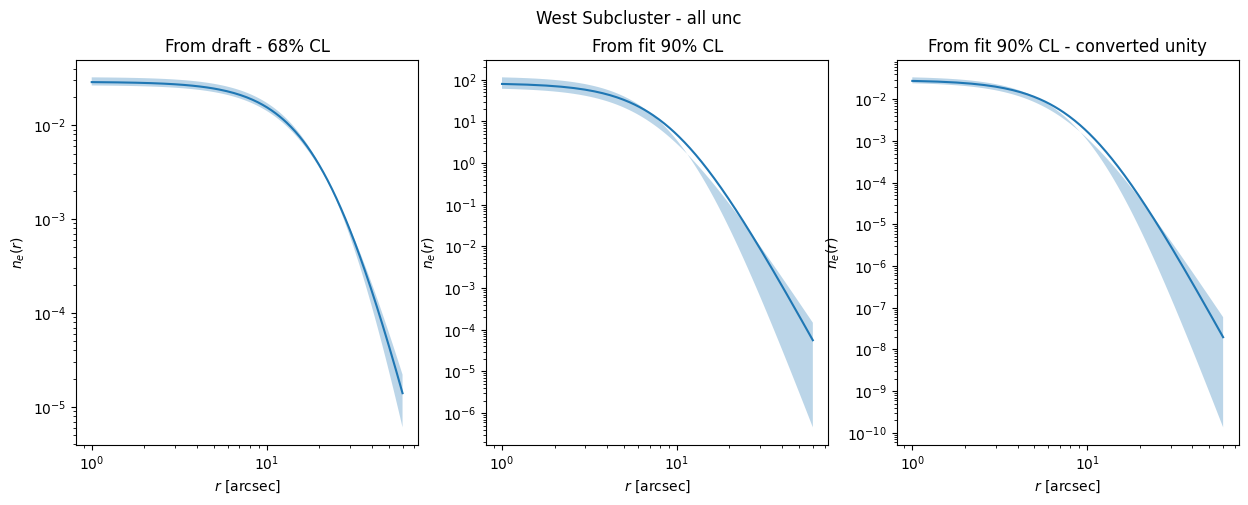

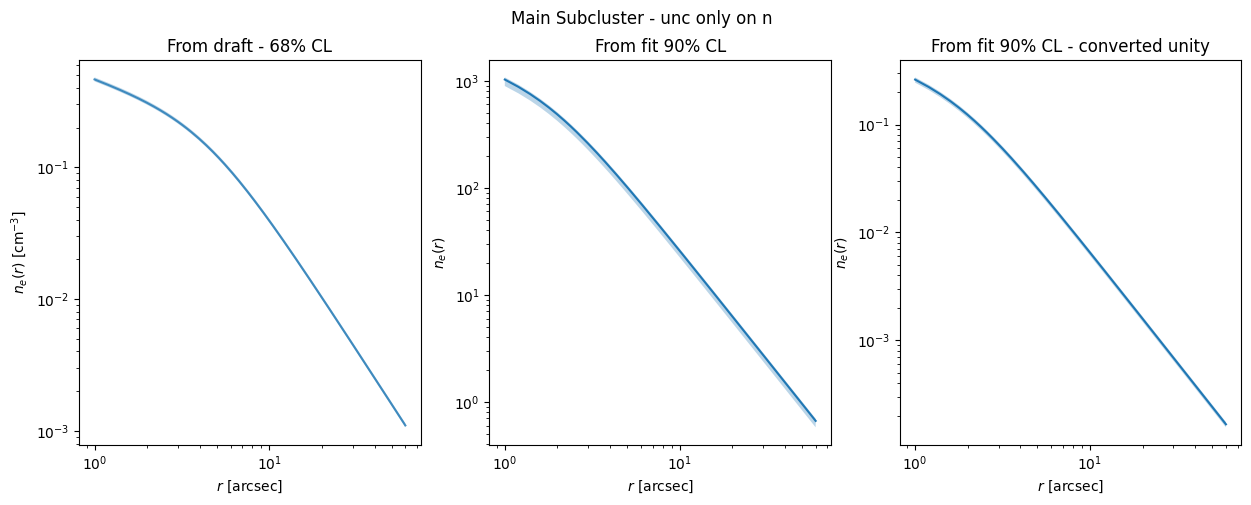

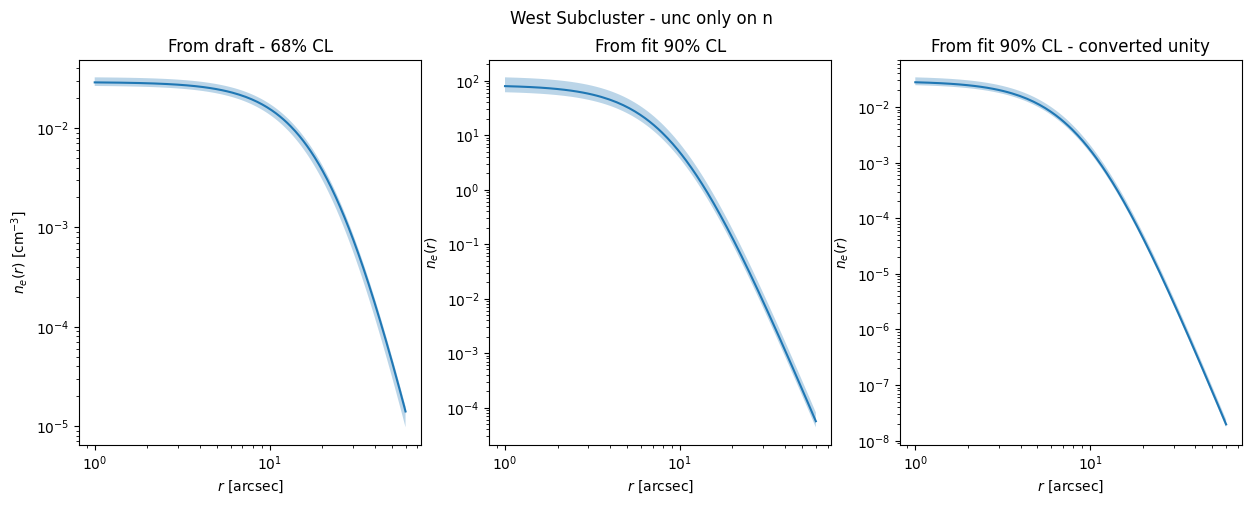

In [ ]:

# fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# plt.suptitle('Main cluster - all unc')
# #### DATA FROM DRAFT  ####
# main = gNFW(0.241, R_vals, 4.33, 2.26, 2.05, 0.465)
# main_majunc = gNFW(0.241+0.009, R_vals, 4.33+0.95, 2.26, 2.05+0.23, 0.465)
# main_minunc = gNFW(0.241-0.008, R_vals, 4.33-0.59, 2.26, 2.05-0.13, 0.465)
# axs[0].loglog(R_vals, main)
# #plt.plot(R_vals, main_minunc)
# #plt.plot(R_vals, main_majunc)
# axs[0].fill_between(R_vals, main_minunc, main_majunc, alpha=0.3)
# axs[0].set_xlabel(r'$r$ [arcsec]')
# axs[0].set_ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
# axs[0].set_title('From draft - 68% CL')
# ### DATA FROM pocoMC results with 90% confidence levels ###
# R_vals = np.linspace(1, 60, 300) # arcsec
# main = gNFW(results[8][0], R_vals, results[4][0], 2.26, results[6][0]/2, 0.465)
# main_majunc = gNFW(results[8][0]+results[8][2], R_vals, results[4][0]+results[4][2], 2.26, results[6][0]/2+results[6][2]/2, 0.465)
# main_minunc = gNFW(results[8][0]-results[8][1], R_vals, results[4][0]-results[4][1], 2.26, results[6][0]/2-results[6][1]/2, 0.465)
# axs[1].loglog(R_vals, main)
# #plt.plot(R_vals, main_minunc)
# #plt.plot(R_vals, main_majunc)
# axs[1].fill_between(R_vals, main_minunc, main_majunc, alpha=0.3)
# # for i in range(100):
# #     #idx=np.random.randint(int(len(samples) - len(samples)/4), len(samples))
# #     x_main_mcmc, y_main_mcmc, x_sub_mcmc, y_sub_mcmc, rs_main_mcmc, rc_sub_mcmc, beta_main_mcmc, beta_sub_mcmc, A_main_mcmc, A_sub_mcmc, a_bkg_mcmc  = (samples[-i])
    
# #     main = lambda r : gNFW(A_main_mcmc, r, rs_main_mcmc, alpha_main, beta_main_mcmc/2, gamma_main)

# #     plt.loglog(R_vals, main(R_vals), color="gray", alpha=0.05)
# axs[1].set_xlabel(r'$r$ [arcsec]')
# axs[1].set_ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
# axs[1].set_title('From fit 90% CL')
# #### DATA FROM pocoMC with 90% CL converted unity####
# a = 0.241/948
# a1 = 0.009/35 # +
# a2 = 0.008/65 # -
# b = 0.0290/82.9
# b1 = 0.0036/20.5 # +
# b2 = 0.0023/13.1 # -
# R_vals = np.linspace(1, 60, 300) # arcsec
# main = gNFW(results[8][0]*a, R_vals, results[4][0], 2.26, results[6][0]/2, 0.465)
# main_majunc = gNFW(results[8][0]*a+results[8][2]*a1, R_vals, results[4][0]+results[4][2], 2.26, results[6][0]/2+results[6][2]/2, 0.465)
# main_minunc = gNFW(results[8][0]*a-results[8][1]*a2, R_vals, results[4][0]-results[4][1], 2.26, results[6][0]/2-results[6][1]/2, 0.465)
# axs[2].loglog(R_vals, main)
# axs[2].fill_between(R_vals, main_minunc, main_majunc, alpha=0.3)
# axs[2].set_xlabel(r'$r$ [arcsec]')
# axs[2].set_ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
# axs[2].set_title('From fit 90% CL - converted unity')
# plt.show()



# fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# plt.suptitle('West Subcluster - all unc')
# #### DATA FROM DRAFT  ####
# sub = isobeta(0.0290, R_vals, 23.9, 2.56)
# sub_majunc = isobeta(0.0290+0.0036, R_vals, 23.9+2.7, 2.56+0.61)
# sub_minunc = isobeta(0.0290-0.0023, R_vals, 23.9-2.0, 2.56-0.35)
# axs[0].loglog(R_vals, sub)
# #plt.plot(R_vals, sub_majunc)
# #plt.plot(R_vals, sub_minunc)
# axs[0].fill_between(R_vals, sub_minunc, sub_majunc, alpha=0.3)
# axs[0].set_xlabel(r'$r$ [arcsec]')
# axs[0].set_ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
# axs[0].set_title('From draft - 68% CL')
# ### DATA FROM pocoMC results with 90% confidence levels ###
# sub = isobeta(results[9][0], R_vals, results[5][0], results[7][0])
# sub_majunc = isobeta(results[9][0]+results[9][2], R_vals, results[5][0]+results[5][2], results[7][0]+results[7][2])
# sub_minunc = isobeta(results[9][0]-results[9][1], R_vals, results[5][0]-results[5][1], results[7][0]-results[7][1])
# axs[1].loglog(R_vals, sub)
# #plt.plot(R_vals, sub_majunc)
# #plt.plot(R_vals, sub_minunc)
# axs[1].fill_between(R_vals, sub_minunc, sub_majunc, alpha=0.3)
# # for i in range(50):
# #     #idx=np.random.randint(int(len(samples) - len(samples)/4), len(samples))
# #     x_main_mcmc, y_main_mcmc, x_sub_mcmc, y_sub_mcmc, rs_main_mcmc, rc_sub_mcmc, beta_main_mcmc, beta_sub_mcmc, A_main_mcmc, A_sub_mcmc, a_bkg_mcmc  = (samples[-i])

# #     sub = lambda r : isobeta(A_sub_mcmc, r, rc_sub_mcmc, beta_sub_mcmc)

# #     plt.loglog(R_vals, sub(R_vals), color="gray", alpha=0.05)
# axs[1].set_xlabel(r'$r$ [arcsec]')
# axs[1].set_ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
# axs[1].set_title('From fit 90% CL')
# #### DATA FROM pocoMC with 90% CL converted unity####
# sub = isobeta(results[9][0]*b, R_vals, results[5][0], results[7][0])
# sub_majunc = isobeta(results[9][0]*b+results[9][2]*b1, R_vals, results[5][0]+results[5][2], results[7][0]+results[7][2])
# sub_minunc = isobeta(results[9][0]*b-results[9][1]*b2, R_vals, results[5][0]-results[5][1], results[7][0]-results[7][1])
# axs[2].loglog(R_vals, sub)
# axs[2].fill_between(R_vals, sub_minunc, sub_majunc, alpha=0.3)
# axs[2].set_xlabel(r'$r$ [arcsec]')
# axs[2].set_ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
# axs[2].set_title('From fit 90% CL - converted unity')
# plt.show()



# fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# plt.suptitle('Main Subcluster - unc only on n')
# #### DATA FROM DRAFT  ####
# main = gNFW(0.241, R_vals, 4.33, 2.26, 2.05, 0.465)
# main_majunc = gNFW(0.241+0.009, R_vals, 4.33, 2.26, 2.05, 0.465) #gNFW(0.241+0.009, R_vals, 36.9+8.1, 2.26, 2.05+0.23, 0.465)
# main_minunc = gNFW(0.241-0.008, R_vals, 4.33, 2.26, 2.05, 0.465) #gNFW(0.241-0.008, R_vals, 36.9-5.0, 2.26, 2.05-0.13, 0.465)
# axs[0].loglog(R_vals, main, alpha=0.8)
# #plt.plot(R_vals, main_minunc)
# #plt.plot(R_vals, main_majunc)
# axs[0].fill_between(R_vals, main_minunc, main_majunc, alpha=0.3)
# axs[0].set_xlabel(r'$r$ [arcsec]')
# axs[0].set_ylabel(r'$n_e(r)$ [cm$^{-3}$]')
# axs[0].set_title('From draft - 68% CL')
# ### DATA FROM pocoMC results with 90% confidence levels ###
# R_vals = np.linspace(1, 60, 300) # arcsec
# main = gNFW(results[8][0], R_vals, results[4][0], 2.26, 2.05, 0.465)
# main_majunc = gNFW(results[8][0]+results[8][2], R_vals, results[4][0], 2.26, 2.05, 0.465)
# main_minunc = gNFW(results[8][0]-results[8][1], R_vals, results[4][0], 2.26, 2.05, 0.465)
# axs[1].loglog(R_vals, main)
# #plt.plot(R_vals, main_minunc)
# #plt.plot(R_vals, main_majunc)
# axs[1].fill_between(R_vals, main_minunc, main_majunc, alpha=0.3)
# axs[1].set_xlabel(r'$r$ [arcsec]')
# axs[1].set_ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
# axs[1].set_title('From fit 90% CL')
# #### DATA FROM pocoMC with 90% CL converted unity####
# main = gNFW(results[8][0]*a, R_vals, results[4][0], 2.26, results[6][0]/2, 0.465)
# main_majunc = gNFW(results[8][0]*a+results[8][2]*a1, R_vals, results[4][0], 2.26, results[6][0]/2, 0.465)
# main_minunc = gNFW(results[8][0]*a-results[8][1]*a2, R_vals, results[4][0], 2.26, results[6][0]/2, 0.465)
# axs[2].loglog(R_vals, main)
# axs[2].fill_between(R_vals, main_minunc, main_majunc, alpha=0.3)
# axs[2].set_xlabel(r'$r$ [arcsec]')
# axs[2].set_ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
# axs[2].set_title('From fit 90% CL - converted unity')
# plt.show()


# fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# plt.suptitle('West Subcluster - unc only on n')
# #### DATA FROM DRAFT  ####
# sub = isobeta(0.0290, R_vals, 23.9, 2.56)
# sub_majunc = isobeta(0.0290+0.0036, R_vals, 23.9, 2.56) #isobeta(0.0290+0.0036, R_vals, 204+23, 2.56+0.61)
# sub_minunc = isobeta(0.0290-0.0023, R_vals, 22.9, 2.56) #isobeta(0.0290-0.0023, R_vals, 204-20, 2.56-0.35) 
# axs[0].loglog(R_vals, sub)
# #plt.plot(R_vals, sub_majunc)
# #plt.plot(R_vals, sub_minunc)
# axs[0].fill_between(R_vals, sub_minunc, sub_majunc, alpha=0.3)
# axs[0].set_xlabel(r'$r$ [arcsec]')
# axs[0].set_ylabel(r'$n_e(r)$ [cm$^{-3}$]')
# axs[0].set_title('From draft - 68% CL')
# ### DATA FROM pocoMC results with 90% confidence levels ###
# R_vals = np.linspace(1, 60, 300) # arcsec
# sub = isobeta(results[9][0], R_vals, results[5][0], results[7][0])
# sub_majunc = isobeta(results[9][0]+results[9][2], R_vals, results[5][0], results[7][0])
# sub_minunc = isobeta(results[9][0]-results[9][1], R_vals, results[5][0], results[7][0])
# axs[1].loglog(R_vals, sub)
# #plt.plot(R_vals, sub_majunc)
# #plt.plot(R_vals, sub_minunc)
# axs[1].fill_between(R_vals, sub_minunc, sub_majunc, alpha=0.3)
# axs[1].set_xlabel(r'$r$ [arcsec]')
# axs[1].set_ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
# axs[1].set_title('From fit 90% CL')
# #### DATA FROM pocoMC with 90% CL converted unity####
# sub = isobeta(results[9][0]*b, R_vals, results[5][0], results[7][0])
# sub_majunc = isobeta(results[9][0]*b+results[9][2]*b1, R_vals, results[5][0], results[7][0])
# sub_minunc = isobeta(results[9][0]*b-results[9][1]*b2, R_vals, results[5][0], results[7][0])
# axs[2].loglog(R_vals, sub)
# axs[2].fill_between(R_vals, sub_minunc, sub_majunc, alpha=0.3)
# axs[2].set_xlabel(r'$r$ [arcsec]')
# axs[2].set_ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
# axs[2].set_title('From fit 90% CL - converted unity')

# plt.show()